# figures for *friends as sensors*

reproduces all figures of the paper from the published data. needs the two dehydrated parquets and the three lead time csvs in `data/` (see DATASHEET.md), writes the svgs to `figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from IPython.display import SVG

sys.path.insert(0, str(Path.cwd()))
import reproduce_paper_figures as rpf

DATA = Path("data")
OUT = Path("figures")
OUT.mkdir(exist_ok=True)

In [2]:
# the published files carry hashed ids and renamed newsguard columns,
# map them back to the names the analysis code expects
rename = {"TWEET_id_hashed": "TWEET_id", "USER_id_hashed": "USER_id",
          "newsguard_scores": "newsguard_scores_expanded"}
cols = list(rename) + ["TWEET_created_at", "referenced_tweet_type",
                       "newsguard_orientation", "impression_count"]
sensor = pd.read_parquet(DATA / "sensor_dehydrated.parquet", columns=cols).rename(columns=rename)
random_df = pd.read_parquet(DATA / "random_dehydrated.parquet", columns=cols).rename(columns=rename)
len(sensor), len(random_df)

(30964074, 27395048)

## figure 1, the friendship paradox in a small network

mean friends 2.00, mean friends of friends 2.47


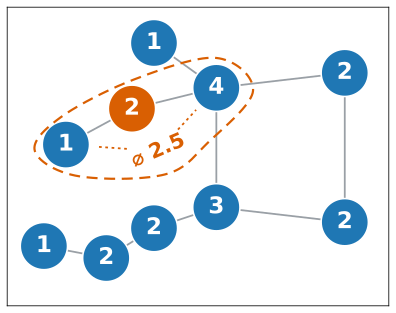

In [3]:
def catmull_rom_closed(P, samples=40):
    # smooth closed curve through the control points
    P = np.asarray(P, float)
    n = len(P)
    out = []
    for i in range(n):
        p0, p1, p2, p3 = P[(i - 1) % n], P[i], P[(i + 1) % n], P[(i + 2) % n]
        t = np.linspace(0, 1, samples, endpoint=False)[:, None]
        out.append(0.5 * ((2 * p1) + (-p0 + p2) * t
                          + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t ** 2
                          + (-p0 + 3 * p1 - 3 * p2 + p3) * t ** 3))
    out.append(out[0][:1])
    return np.vstack(out)


pos = {
    "markab":    (0.55, 0.35),
    "scheat":    (0.55, 0.75),
    "algenib":   (0.90, 0.30),
    "alpheratz": (0.90, 0.80),
    "zeta":      (0.38, 0.28),
    "theta":     (0.25, 0.18),
    "enif":      (0.08, 0.22),
    "eta":       (0.38, 0.90),
    "mu":        (0.32, 0.68),
    "lambda":    (0.14, 0.56),
}
edges = [
    ("markab", "scheat"), ("scheat", "alpheratz"), ("alpheratz", "algenib"),
    ("algenib", "markab"),
    ("markab", "zeta"), ("zeta", "theta"), ("theta", "enif"),
    ("scheat", "eta"), ("scheat", "mu"), ("mu", "lambda"),
]

F = 23
blue, gray, orange = "#1f77b4", "#9aa0a6", "#d95f02"
node_size = 950 * (F / 15.0) ** 2

deg = {n: 0 for n in pos}
adj = {n: [] for n in pos}
for a, b in edges:
    deg[a] += 1; deg[b] += 1
    adj[a].append(b); adj[b].append(a)
fmeans = {n: np.mean([deg[f] for f in adj[n]]) for n in pos}
print(f"mean friends {np.mean(list(deg.values())):.2f}, "
      f"mean friends of friends {np.mean(list(fmeans.values())):.2f}")

fig, ax = plt.subplots(figsize=(5.6, 4.45))
for a, b in edges:
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color=gray,
            lw=1.8, zorder=1)
for n, (x, y) in pos.items():
    ax.scatter([x], [y], s=node_size, color=orange if n == "mu" else blue,
               edgecolor="white", linewidth=1.6, zorder=2)
    ax.text(x, y, str(deg[n]), color="white", ha="center", va="center",
            fontsize=F, fontweight="bold", zorder=3)

# dashed outline around the showcase trio, bulging down to hold the label
blob = catmull_rom_closed([
    (0.055, 0.540), (0.130, 0.655), (0.330, 0.780), (0.550, 0.850),
    (0.650, 0.740), (0.530, 0.570), (0.410, 0.460), (0.170, 0.455),
])
ax.plot(blob[:, 0], blob[:, 1], color=orange, lw=2.2, ls=(0, (5, 3)),
        zorder=4)

# the average label sits on the perpendicular bisector of the 1-4 line so
# the two dotted connectors to the friend nodes come out symmetric
fig.canvas.draw()
T = ax.transData.transform
Ti = ax.transData.inverted().transform
d1, dmu, d4 = T(pos["lambda"]), T(pos["mu"]), T(pos["scheat"])
u = (d4 - d1) / np.linalg.norm(d4 - d1)
perp = np.array([u[1], -u[0]])
if np.dot(dmu - (d1 + d4) / 2.0, perp) > 0:
    perp = -perp
c = (d1 + d4) / 2.0 + 55.0 * perp
r_px = np.sqrt(node_size / np.pi) * fig.dpi / 72.0
for target in (d1, d4):
    dirv = (target - c) / np.linalg.norm(target - c)
    xy0, xy1 = Ti(c + dirv * 40.0), Ti(target - dirv * (r_px + 4.0))
    ax.plot([xy0[0], xy1[0]], [xy0[1], xy1[1]], color=orange, lw=1.8,
            ls=(0, (1.5, 2)), zorder=4)
cxy = Ti(c)
ax.text(cxy[0], cxy[1], "\u2300 2.5", ha="center", va="center",
        rotation=np.degrees(np.arctan2(u[1], u[0])), rotation_mode="anchor",
        fontsize=F * 0.9, fontweight="bold", color=orange, zorder=5)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.02, 1.02)
ax.set_xticks([]); ax.set_yticks([])
for side in ax.spines.values():
    side.set_visible(True); side.set_color("black"); side.set_linewidth(0.8)
plt.tight_layout()
path = OUT / "fp_network_pegasus.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))

## figure 2, newsguard score distributions

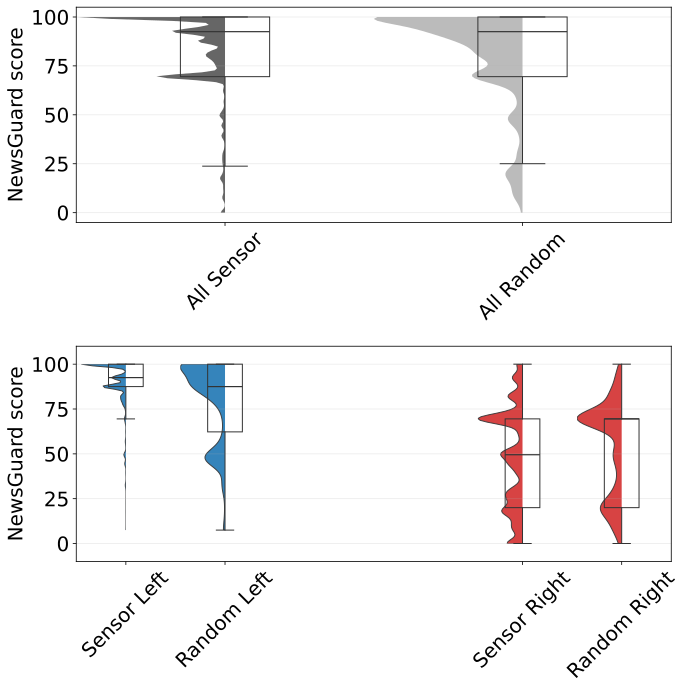

In [4]:
plt.rcParams.update({"font.size": 20, "axes.labelsize": 20,
                     "xtick.labelsize": 20, "ytick.labelsize": 20,
                     "legend.fontsize": 16.4})
path = OUT / "ng_combined_overall_and_left_right.svg"
rpf.plot_ng_overall_and_left_right(sensor, random_df, savepath=path)
SVG(str(path))

## figure 3, newsguard scores over time in both samples

In [5]:
# mean newsguard per tweet, split left/right and original/retweet,
# 3 day buckets over the shared observation window
prepped = []
for df0, name in [(sensor, "sensor"), (random_df, "random")]:
    df = df0.copy()
    df["TWEET_created_at"] = rpf.to_naive_utc(df["TWEET_created_at"])
    df = df[(df["TWEET_created_at"] >= "2024-06-01") &
            (df["TWEET_created_at"] <= "2024-11-01")]
    df["bucket"] = df["TWEET_created_at"].dt.floor("3D")
    ori = df["newsguard_orientation"].map(rpf._to_list)
    tweet_ng = rpf._tweet_mean_newsguard(df)
    tframe = df[["TWEET_id", "bucket"]].copy()
    tframe["is_left"] = ori.map(rpf._has_left).values
    tframe["is_right"] = ori.map(rpf._has_right).values
    tframe["is_ret"] = df["referenced_tweet_type"].map(rpf._is_retweet).values
    tframe = tframe.merge(tweet_ng, on="TWEET_id", how="left").dropna(subset=["tweet_ng"])
    series = {}
    for side, mask_side in [("L", tframe["is_left"]), ("R", tframe["is_right"])]:
        for kind, mask_kind in [("org", ~tframe["is_ret"]), ("ret", tframe["is_ret"])]:
            series[side + kind] = rpf._series_by_kind(
                tframe.rename(columns={"tweet_ng": "val"}), "bucket", "val",
                mask_kind, mask_side).sort_values("bucket")
    prepped.append((series, name))
len(prepped)

2

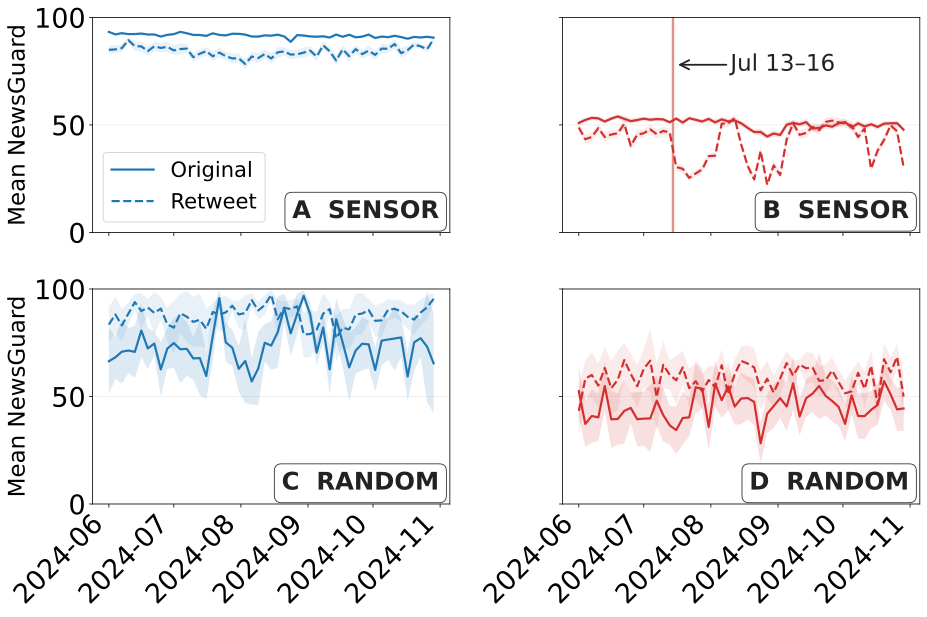

In [6]:
F = 27
plt.rcParams.update({"font.size": F, "axes.labelsize": F,
                     "xtick.labelsize": F, "ytick.labelsize": F})
# columns share their x axis so only the bottom row gets date labels
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2), sharey=True, sharex="col")
fig.subplots_adjust(hspace=0.14, wspace=0.12)
for r, (series, name) in enumerate(prepped):
    axL, axR = axes[r, 0], axes[r, 1]
    for ax, side, color in [(axL, "L", rpf.LEFT_COLOR),
                            (axR, "R", rpf.RIGHT_COLOR)]:
        org, ret = series[side + "org"], series[side + "ret"]
        ax.plot(org["bucket"], org["mean"], color=color, lw=2.2, label="Original")
        ax.fill_between(org["bucket"], org["ci_low"], org["ci_high"],
                        color=color, alpha=0.15, lw=0)
        ax.plot(ret["bucket"], ret["mean"], color=color, lw=2.2, ls="--",
                label="Retweet")
        ax.fill_between(ret["bucket"], ret["ci_low"], ret["ci_high"],
                        color=color, alpha=0.10, lw=0)
        ax.set_ylim(0, 100)
        ax.grid(True, axis="y", alpha=0.25)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45)
            lbl.set_ha("right")
    axL.set_ylabel("Mean NewsGuard", fontsize=F * 0.85)
    if r == 0:
        axL.legend(loc="lower left", fontsize=F * 0.78)
        # musk endorsement window, panel b only
        x_ev = pd.Timestamp("2024-07-14T12:00")
        axR.axvline(x_ev, color=rpf.DECAY_COLOR, alpha=0.55, lw=2.4, zorder=2)
        axR.annotate("Jul 13\u201316", xy=(x_ev, 78),
                     xytext=(pd.Timestamp("2024-08-10"), 78),
                     textcoords="data", ha="left", va="center",
                     fontsize=F * 0.85, color="#222",
                     arrowprops=dict(arrowstyle="->", color="#222", lw=1.8,
                                     shrinkA=2, shrinkB=5))
    for ax, letter in [(axL, ["A", "C"][r]), (axR, ["B", "D"][r])]:
        ax.text(0.97, 0.04, f"{letter}  {name.upper()}", transform=ax.transAxes,
                fontsize=F * 0.9, fontweight="bold", va="bottom", ha="right",
                color="#222",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#222",
                          lw=0.9, alpha=0.9))
plt.tight_layout()
path = OUT / "4panel_events_julyonly.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))

## figure 4, lead time by newsguard score

the pair matching behind this figure needs the raw urls, which the published data can not contain, so this one plots the released aggregates.

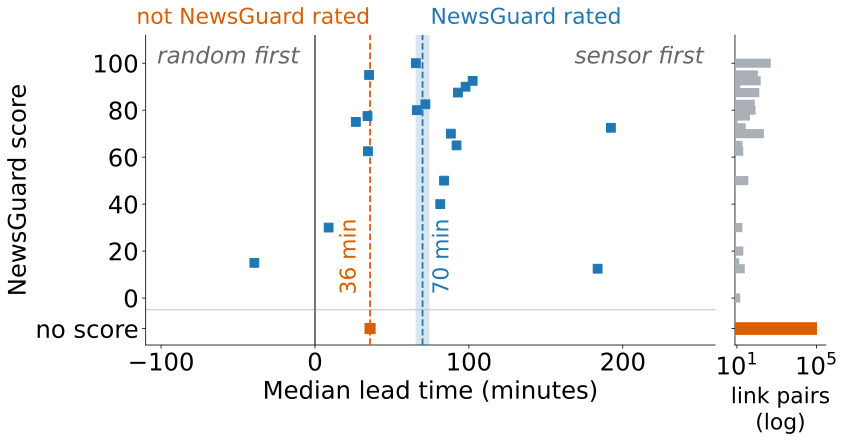

In [7]:
steps = pd.read_csv(DATA / "lead_time_by_ng_score.csv")
rated = pd.read_csv(DATA / "lead_time_overall_rated.csv").iloc[0]
unrated = pd.read_csv(DATA / "lead_time_unrated.csv").iloc[0]

F = 24.3
plt.rcParams.update({"font.size": F, "axes.labelsize": F,
                     "xtick.labelsize": F, "ytick.labelsize": F})
blue, orange, graybar = "#1f77b4", "#d95f02", "#aab0b6"
noscore_y, sep_y = -13.0, -5.0
xlim, ylim = (-110, 260), (-20, 112)

fig = plt.figure(figsize=(12.2, 5.6))
gs = GridSpec(1, 2, width_ratios=[7.2, 1.15], wspace=0.06, figure=fig)
ax = fig.add_subplot(gs[0, 0])
axp = fig.add_subplot(gs[0, 1], sharey=ax)

in_range = steps[(steps["med"] > xlim[0]) & (steps["med"] < xlim[1])]
ax.scatter(in_range["med"], in_range["step"], marker="s", s=F * 3.2,
           color=blue, zorder=4)
ax.scatter([unrated["med"]], [noscore_y], marker="s", s=F * 4.2,
           color=orange, zorder=4)

ax.axvline(0, color="#555", lw=1.6, zorder=2)
ax.axvline(unrated["med"], color=orange, ls="--", lw=1.8, zorder=3)
ax.axvspan(rated["lo50"], rated["hi50"], color=blue, alpha=0.18, zorder=1)
ax.axvline(rated["med"], color=blue, ls="--", lw=1.8, zorder=3)

ax.text(unrated["med"] - 6, 1.5, "36 min", rotation=90, va="bottom",
        ha="right", color=orange, fontsize=F * 0.9)
ax.text(rated["med"] + 6, 1.5, "70 min", rotation=90, va="bottom",
        ha="left", color=blue, fontsize=F * 0.9)
ax.text(0.02, 0.965, "random first", transform=ax.transAxes, ha="left",
        va="top", fontstyle="italic", color="#666", fontsize=F * 0.95)
ax.text(0.98, 0.965, "sensor first", transform=ax.transAxes, ha="right",
        va="top", fontstyle="italic", color="#666", fontsize=F * 0.95)
ax.annotate("not NewsGuard rated", xy=(unrated["med"], 1.0),
            xycoords=("data", "axes fraction"), xytext=(0, 6),
            textcoords="offset points", ha="right", va="bottom",
            color=orange, fontsize=F * 0.9, annotation_clip=False)
ax.annotate("NewsGuard rated", xy=(rated["med"], 1.0),
            xycoords=("data", "axes fraction"), xytext=(8, 6),
            textcoords="offset points", ha="left", va="bottom",
            color=blue, fontsize=F * 0.9, annotation_clip=False)

ax.axhline(sep_y, color="#bbb", lw=0.9, zorder=1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
yt = [0, 20, 40, 60, 80, 100]
ax.set_yticks(yt + [noscore_y])
ax.set_yticklabels([str(v) for v in yt] + ["no score"])
ax.set_xlabel("Median lead time (minutes)")
ax.set_ylabel("NewsGuard score")

# marginal, pair counts per score row
barh = max(2.2, F * 0.16)
axp.barh(steps["step"], steps["mean_pairs"], height=barh, color=graybar, zorder=3)
axp.barh([noscore_y], [unrated["pairs"]], height=barh * 1.4, color=orange, zorder=3)
axp.set_xscale("log")
axp.set_xlim(8, 3e5)
axp.set_xticks([1e1, 1e5])
axp.set_xlabel("link pairs\n(log)", fontsize=F * 0.9)
axp.tick_params(axis="y", labelleft=False)
for a in (ax, axp):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

path = OUT / "lead_time_solar_final.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))

## figure 5, impressions and newsguard scores over time, sensor sample

In [8]:
analysis = rpf.analyze_impressions_by_orientation(sensor, freq="3D",
                                                  tweet_kind="original")

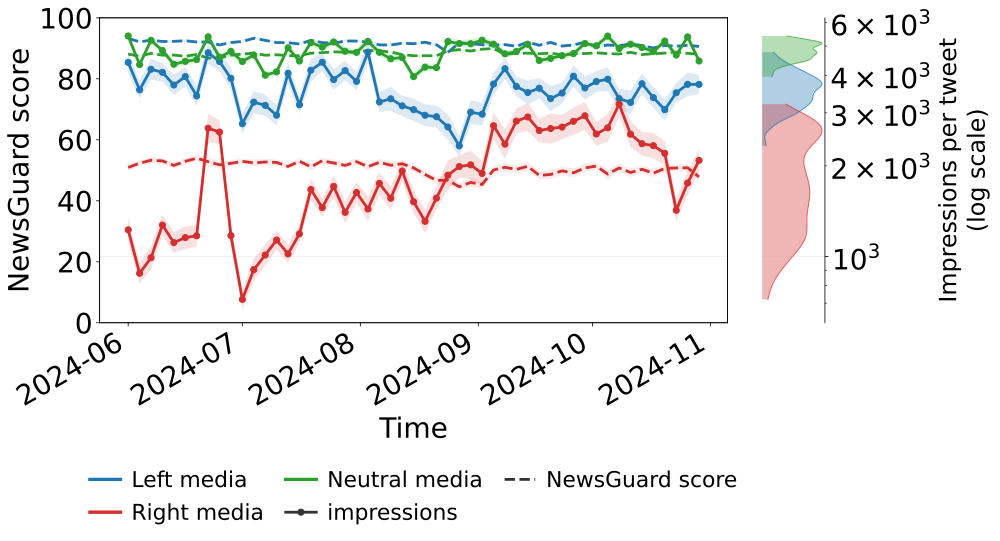

In [9]:
F = 28
plt.rcParams.update({"font.size": F, "axes.labelsize": F,
                     "xtick.labelsize": F, "ytick.labelsize": F})
weekly = analysis["weekly"]
ll, rl, nl = (analysis["left_label"], analysis["right_label"],
              analysis["neutral_label"])
colors = {ll: rpf.LEFT_COLOR, rl: rpf.RIGHT_COLOR, nl: rpf.NEUTRAL_COLOR}

fig = plt.figure(figsize=(13, 5.5))
gs = GridSpec(1, 2, width_ratios=[10, 1], wspace=0.10, figure=fig)
ax = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
ax2 = ax.twinx()

# impressions, read on the right axis next to the marginal
for g in [ll, rl, nl]:
    sub = weekly[weekly["group"] == g].sort_values("bucket")
    ax2.plot(sub["bucket"], sub["mean_impr"], "-o", ms=F * 0.22, lw=F * 0.1,
             color=colors[g])
    ax2.fill_between(sub["bucket"], sub["ci_low_impr"], sub["ci_high_impr"],
                     color=colors[g], alpha=0.15, lw=0)
ax2.set_yscale("log")
ax2.tick_params(axis="y", which="both", labelright=False, right=False)
ax2.grid(True, axis="y", alpha=0.2)

# newsguard scores, dashed, left axis
for g in [ll, rl, nl]:
    sub = weekly[weekly["group"] == g].sort_values("bucket")
    if sub["mean_ng"].isna().all():
        continue
    ax.plot(sub["bucket"], sub["mean_ng"], "--", lw=F * 0.1, color=colors[g])
    ax.fill_between(sub["bucket"], sub["ci_low_ng"], sub["ci_high_ng"],
                    color=colors[g], alpha=0.10, lw=0)
ax.set_ylabel("NewsGuard score")
ax.set_ylim(0, 100)
ax.set_xlabel("Time")
for lbl in ax.get_xticklabels():
    lbl.set_rotation(30)
    lbl.set_ha("right")

handles = [
    Line2D([], [], color=colors[ll], lw=F * 0.12, label=ll),
    Line2D([], [], color=colors[rl], lw=F * 0.12, label=rl),
    Line2D([], [], color=colors[nl], lw=F * 0.12, label=nl),
    Line2D([], [], color="#333", lw=F * 0.1, marker="o", ms=F * 0.22,
           label="impressions"),
    Line2D([], [], color="#333", lw=F * 0.1, ls="--", label="NewsGuard score"),
]
ax.legend(handles=handles, loc="upper center", ncol=3, frameon=False,
          bbox_to_anchor=(0.5, -0.42), fontsize=F * 0.78,
          handlelength=1.4, columnspacing=1.0, handletextpad=0.5)

# marginal distribution of the impression series
for g in [ll, rl, nl]:
    vals = weekly.loc[weekly["group"] == g, "mean_impr"].dropna().values
    vals = vals[vals > 0]
    log_vals = np.log(vals)
    kde = gaussian_kde(log_vals, bw_method=0.3)
    y_grid = np.linspace(log_vals.min(), log_vals.max(), 300)
    density = kde(y_grid)
    density = density / density.max()
    ax_dist.fill_betweenx(np.exp(y_grid), 0, density, color=colors[g],
                          alpha=0.35, linewidth=0)
    ax_dist.plot(density, np.exp(y_grid), color=colors[g], lw=1.0, alpha=0.7)
ax_dist.set_yscale("log")
ax_dist.set_ylim(ax2.get_ylim())
ax_dist.set_xlim(0, None)
ax_dist.grid(True, axis="y", alpha=0.2)
ax_dist.tick_params(axis="y", which="both", labelleft=False, left=False,
                    labelright=True, right=True)
ax_dist.yaxis.set_label_position("right")
ax_dist.set_ylabel("Impressions per tweet\n(log scale)", fontsize=F * 0.85)
ax_dist.tick_params(axis="x", labelbottom=False, bottom=False)
for side in ["top", "bottom", "left"]:
    ax_dist.spines[side].set_visible(False)

plt.tight_layout()
path = OUT / "ng_impressions_left_right_neutral_log1p.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))

## figure 6, share weighted impressions on unrated tweets, sensor

In [10]:
d = rpf._build_base_frame(sensor, start="2024-06-01", end="2024-11-01",
                          freq="3D")
user_lean = rpf._classify_users_for_share_weighted(d, min_ng=5)
non_ng = rpf._build_non_ng_frame(d, user_lean)
print(f"{len(user_lean):,} users in the pool, {len(non_ng):,} unrated tweets")
frames = {s: rpf._weighted_bucket_stats(non_ng, s) for s in rpf.SHARES}

1,815 users in the pool, 5,324,274 unrated tweets


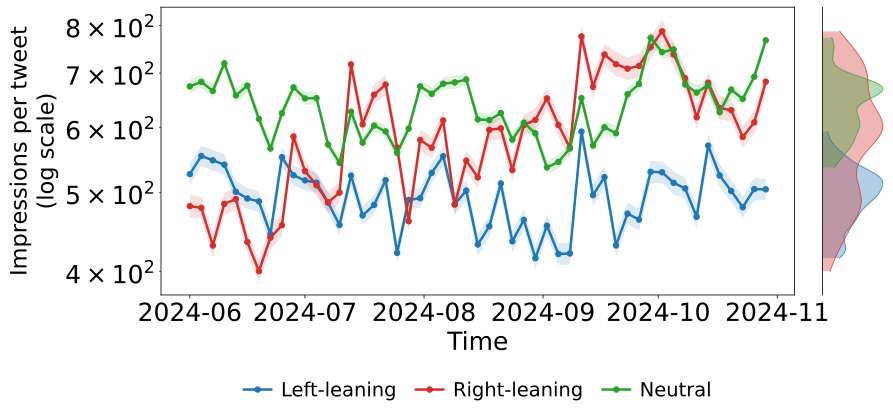

In [11]:
F = 25
plt.rcParams.update({"font.size": F, "axes.labelsize": F,
                     "xtick.labelsize": F, "ytick.labelsize": F})
fig = plt.figure(figsize=(13, 5.2))
gs = GridSpec(1, 2, width_ratios=[10, 1], wspace=0.08, figure=fig)
ax = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
for s in rpf.SHARES:
    sub = frames[s].sort_values("bucket")
    m = np.expm1(sub["mean_log"]).clip(lower=1.0)
    lo = np.expm1(sub["ci_lo"]).clip(lower=1.0)
    hi = np.expm1(sub["ci_hi"]).clip(lower=1.0)
    ax.plot(sub["bucket"], m, "-o", ms=F * 0.22, lw=F * 0.1,
            color=rpf.SHARE_COLORS[s], label=rpf.SHARE_LABELS[s])
    ax.fill_between(sub["bucket"], lo, hi, color=rpf.SHARE_COLORS[s],
                    alpha=0.15, lw=0)
ax.set_yscale("log")
ax.set_ylabel("Impressions per tweet\n(log scale)", fontsize=F * 0.9)
ax.set_xlabel("Time")
ax.grid(True, axis="y", alpha=0.2)
ax.legend(loc="upper center", ncol=3, frameon=False,
          bbox_to_anchor=(0.5, -0.24), fontsize=F * 0.78,
          handlelength=1.4, columnspacing=1.0, handletextpad=0.5)
for s in rpf.SHARES:
    vals = np.expm1(frames[s]["mean_log"]).dropna().values
    vals = vals[vals > 0]
    log_vals = np.log(vals)
    kde = gaussian_kde(log_vals, bw_method=0.3)
    y_grid = np.linspace(log_vals.min(), log_vals.max(), 300)
    density = kde(y_grid)
    density = density / density.max()
    ax_dist.fill_betweenx(np.exp(y_grid), 0, density,
                          color=rpf.SHARE_COLORS[s], alpha=0.35, linewidth=0)
    ax_dist.plot(density, np.exp(y_grid), color=rpf.SHARE_COLORS[s],
                 lw=1.0, alpha=0.7)
ax_dist.set_yscale("log")
ax_dist.set_ylim(ax.get_ylim())
ax_dist.set_xlim(0, None)
ax_dist.grid(True, axis="y", alpha=0.2)
ax_dist.tick_params(axis="y", which="both", labelleft=False, left=False,
                    labelright=False, right=False)
ax_dist.tick_params(axis="x", labelbottom=False, bottom=False)
for side in ["top", "right", "bottom"]:
    ax_dist.spines[side].set_visible(False)
plt.tight_layout()
path = OUT / "tweet_exposure_weighted_trend.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))

## figure a1, same thing for the random sample

In [12]:
d = rpf._build_base_frame(random_df, start="2024-06-01", end="2024-11-01",
                          freq="3D")
user_lean = rpf._classify_users_for_share_weighted(d, min_ng=5)
non_ng = rpf._build_non_ng_frame(d, user_lean)
print(f"{len(user_lean):,} users in the pool, {len(non_ng):,} unrated tweets")
frames = {s: rpf._weighted_bucket_stats(non_ng, s) for s in rpf.SHARES}

272 users in the pool, 271,661 unrated tweets


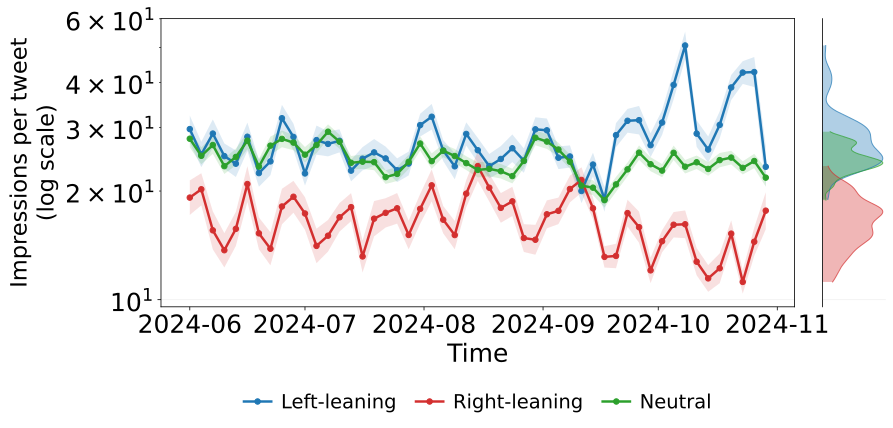

In [13]:
# same plot as figure 6
F = 25
plt.rcParams.update({"font.size": F, "axes.labelsize": F,
                     "xtick.labelsize": F, "ytick.labelsize": F})
fig = plt.figure(figsize=(13, 5.2))
gs = GridSpec(1, 2, width_ratios=[10, 1], wspace=0.08, figure=fig)
ax = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
for s in rpf.SHARES:
    sub = frames[s].sort_values("bucket")
    m = np.expm1(sub["mean_log"]).clip(lower=1.0)
    lo = np.expm1(sub["ci_lo"]).clip(lower=1.0)
    hi = np.expm1(sub["ci_hi"]).clip(lower=1.0)
    ax.plot(sub["bucket"], m, "-o", ms=F * 0.22, lw=F * 0.1,
            color=rpf.SHARE_COLORS[s], label=rpf.SHARE_LABELS[s])
    ax.fill_between(sub["bucket"], lo, hi, color=rpf.SHARE_COLORS[s],
                    alpha=0.15, lw=0)
ax.set_yscale("log")
ax.set_ylabel("Impressions per tweet\n(log scale)", fontsize=F * 0.9)
ax.set_xlabel("Time")
ax.grid(True, axis="y", alpha=0.2)
ax.legend(loc="upper center", ncol=3, frameon=False,
          bbox_to_anchor=(0.5, -0.24), fontsize=F * 0.78,
          handlelength=1.4, columnspacing=1.0, handletextpad=0.5)
for s in rpf.SHARES:
    vals = np.expm1(frames[s]["mean_log"]).dropna().values
    vals = vals[vals > 0]
    log_vals = np.log(vals)
    kde = gaussian_kde(log_vals, bw_method=0.3)
    y_grid = np.linspace(log_vals.min(), log_vals.max(), 300)
    density = kde(y_grid)
    density = density / density.max()
    ax_dist.fill_betweenx(np.exp(y_grid), 0, density,
                          color=rpf.SHARE_COLORS[s], alpha=0.35, linewidth=0)
    ax_dist.plot(density, np.exp(y_grid), color=rpf.SHARE_COLORS[s],
                 lw=1.0, alpha=0.7)
ax_dist.set_yscale("log")
ax_dist.set_ylim(ax.get_ylim())
ax_dist.set_xlim(0, None)
ax_dist.grid(True, axis="y", alpha=0.2)
ax_dist.tick_params(axis="y", which="both", labelleft=False, left=False,
                    labelright=False, right=False)
ax_dist.tick_params(axis="x", labelbottom=False, bottom=False)
for side in ["top", "right", "bottom"]:
    ax_dist.spines[side].set_visible(False)
plt.tight_layout()
path = OUT / "tweet_exposure_weighted_trend_random.svg"
fig.savefig(path, format="svg", bbox_inches="tight")
plt.close(fig)
SVG(str(path))